# 0825_kimjaehak_008_walk_forward_threshold

`kimjaehak_006`의 검사유형별 XGBoost 5개를 고정한 채, 직전 시간 구간에서 선택한 `inspection_type`별 threshold를 다음 구간에 적용합니다.

핵심 질문은 **미래 라벨을 보지 않고 Slip Rate 1% 안전 제약을 지키면서 수동 재검사를 얼마나 줄일 수 있는가**입니다.

## 1. 설정과 라이브러리

모델은 W01~W06으로 한 번만 학습합니다. threshold는 W07→W08, W08→W09, W09→W10 순서로 갱신·평가합니다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

EXPERIMENT_ID = "0825_kimjaehak_008_walk_forward_threshold"
RANDOM_STATE = 42
DATA_PATH = Path("../data/raw/dataset.csv")
MAPPING_PATH = Path("../data/raw/mapping.json")
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"
N_WINDOWS = 10
TRAIN_WINDOWS = [f"W{number:02d}" for number in range(1, 7)]
WALK_FORWARD_PAIRS = [("W07", "W08"), ("W08", "W09"), ("W09", "W10")]
FIXED_THRESHOLD = 0.5
MAX_SLIP_RATE = 0.01
MIN_POSITIVES_FOR_UPDATE = 20
MIN_NEGATIVES_FOR_UPDATE = 100
INITIAL_SAFE_THRESHOLD = 0.0

assert DATA_PATH.exists(), f"파일을 찾을 수 없습니다: {DATA_PATH.resolve()}"
assert MAPPING_PATH.exists(), f"파일을 찾을 수 없습니다: {MAPPING_PATH.resolve()}"
print("experiment:", EXPERIMENT_ID)
print("walk-forward pairs:", WALK_FORWARD_PAIRS)

experiment: 0825_kimjaehak_008_walk_forward_threshold
walk-forward pairs: [('W07', 'W08'), ('W08', 'W09'), ('W09', 'W10')]


## 2. 데이터 로딩과 baseline 기준 중복 제거

`record_id`와 `timestamp`를 제외한 나머지 컬럼과 `class`가 모두 같은 행은 첫 행만 유지합니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

required_columns = {RECORD_ID, TIME_COLUMN, TYPE_COLUMN, TARGET}
missing_columns = required_columns - set(raw_df.columns)
assert not missing_columns, f"필수 컬럼 누락: {missing_columns}"

dedup_columns = [
    column for column in raw_df.columns if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)
clean_df[TIME_COLUMN] = pd.to_datetime(clean_df[TIME_COLUMN], errors="raise", utc=True)
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind="stable").reset_index(drop=True)

assert not clean_df.duplicated(subset=dedup_columns, keep=False).any()
assert len(clean_df) + int(duplicate_mask.sum()) == len(raw_df)

pd.Series({
    "raw_rows": len(raw_df),
    "duplicates_removed": int(duplicate_mask.sum()),
    "deduplicated_rows": len(clean_df),
}, name="data_preparation")

raw_rows              440274
duplicates_removed     48282
deduplicated_rows     391992
Name: data_preparation, dtype: int64

## 3. timestamp-group 기준 10개 시간 구간

누적 행 수 약 10% 간격으로 경계를 잡되 같은 timestamp는 쪼개지 않습니다. W01~W06은 모델 학습, W07~W10은 순차 threshold 갱신과 평가에 사용합니다.

In [3]:
timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

def boundary_time(fraction):
    position = int(np.searchsorted(cumulative_rows, len(clean_df) * fraction, side="left"))
    return timestamp_group_sizes.index[position]

window_end_times = pd.DatetimeIndex(
    [boundary_time(fraction) for fraction in np.arange(0.1, 1.01, 0.1)]
)
window_number = np.searchsorted(
    window_end_times.astype("int64").to_numpy(),
    clean_df[TIME_COLUMN].astype("int64").to_numpy(),
    side="left",
)
clean_df["window"] = pd.Categorical(
    [f"W{number + 1:02d}" for number in window_number],
    categories=[f"W{number:02d}" for number in range(1, N_WINDOWS + 1)],
    ordered=True,
)

window_type_summary = clean_df.groupby(
    ["window", TYPE_COLUMN], observed=False
).agg(
    rows=(TARGET, "size"),
    positives=(TARGET, "sum"),
    positive_rate=(TARGET, "mean"),
)
window_type_summary["negatives"] = (
    window_type_summary["rows"] - window_type_summary["positives"]
)
window_type_summary["positive_rate_pct"] = window_type_summary["positive_rate"] * 100

assert clean_df.groupby(TIME_COLUMN)["window"].nunique().max() == 1
display(window_type_summary.loc[["W07", "W08", "W09", "W10"]])

rows  positives  positive_rate  negatives  \
window inspection_type                                               
W07    0                11337          1       0.000088      11336   
       1                 4480         25       0.005580       4455   
       2                11359          7       0.000616      11352   
       3                11703          3       0.000256      11700   
       4                  301          0       0.000000        301   
W08    0                12155          7       0.000576      12148   
       1                 6014        214       0.035584       5800   
       2                 4538         25       0.005509       4513   
       3                15625         21       0.001344      15604   
       4                  862         60       0.069606        802   
W09    0                10115         65       0.006426      10050   
       1                 4822        131       0.027167       4691   
       2                10635        407       0.038270      10228   
       3                13577        325       0.023938      13252   
       4                   48         13       0.270833         35   
W10    0                 6669         68       0.010196       6601   
       1                 6290        653       0.103816       5637   
       2                 8518        296       0.034750       8222   
       3                17014        278       0.016339      16736   
       4                  708         13       0.018362        695   

                        positive_rate_pct  
window inspection_type                     
W07    0                         0.008821  
       1                         0.558036  
       2                         0.061625  
       3                         0.025634  
       4                         0.000000  
W08    0                         0.057589  
       1                         3.558364  
       2                         0.550903  
       3                         0.134400  
       4                         6.960557  
W09    0                         0.642610  
       1                         2.716715  
       2                         3.826986  
       3                         2.393754  
       4                        27.083333  
W10    0                         1.019643  
       1                        10.381558  
       2                         3.474994  
       3                         1.633949  
       4                         1.836158

## 4. mapping 기반 피처와 고정 모델 학습

각 모델은 공통 `meta_feat`와 `mapping.json`에 정의된 해당 type의 `inspection_feat`만 사용합니다. `kimjaehak_006`과 동일한 XGBoost 설정으로 W01~W06을 학습하고, W07~W10의 확률을 한 번 계산합니다.

In [4]:
inspection_types = sorted(clean_df[TYPE_COLUMN].unique().tolist())
with MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    feature_mapping = json.load(mapping_file)
assert set(feature_mapping) == {str(value) for value in inspection_types}

meta_columns = [column for column in clean_df.columns if column.startswith("meta_feat")]
feature_columns_by_type = {}
models_by_type = {}
future_probability = pd.Series(np.nan, index=clean_df.index, dtype="float64")
training_rows = []

train_mask = clean_df["window"].isin(TRAIN_WINDOWS)
validation_mask = clean_df["window"].isin(["W07", "W08"])

for inspection_type in inspection_types:
    mapped_columns = feature_mapping[str(inspection_type)]
    assert len(mapped_columns) == len(set(mapped_columns))
    assert not (set(mapped_columns) - set(clean_df.columns))
    feature_columns = meta_columns + mapped_columns
    feature_columns_by_type[inspection_type] = feature_columns

    type_train = clean_df.loc[train_mask & (clean_df[TYPE_COLUMN] == inspection_type)]
    type_validation = clean_df.loc[
        validation_mask & (clean_df[TYPE_COLUMN] == inspection_type)
    ]
    type_future = clean_df.loc[
        (~train_mask) & (clean_df[TYPE_COLUMN] == inspection_type)
    ]

    model = XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
    )
    model.fit(
        type_train[feature_columns],
        type_train[TARGET].astype("int8"),
        eval_set=[(
            type_validation[feature_columns],
            type_validation[TARGET].astype("int8"),
        )],
        verbose=False,
    )
    models_by_type[inspection_type] = model
    future_probability.loc[type_future.index] = model.predict_proba(
        type_future[feature_columns]
    )[:, 1]
    training_rows.append({
        "inspection_type": inspection_type,
        "train_rows": len(type_train),
        "train_positives": int(type_train[TARGET].sum()),
        "features": len(feature_columns),
    })

assert future_probability.loc[~train_mask].notna().all()
training_summary = pd.DataFrame(training_rows).set_index("inspection_type")
training_summary

,train_rows,train_positives,features
inspection_type,,,
0,41961,57,48
1,34041,555,56
2,74910,579,69
3,80792,620,69
4,3518,13,25


## 5. 안전 제약 threshold 선택 함수

직전 구간에서 허용되는 FN 수는 `floor(양성 수 × 1%)`입니다. 이 범위 안에서 가장 높은 threshold를 골라 TN을 최대화합니다.

양성 20개 또는 음성 100개 미만이면 새 값을 추정하지 않습니다. 이전 threshold가 없으면 `0`으로 두어 전량 재검사하고, 이후에는 직전 값을 유지합니다.

In [5]:
def safe_average_precision(y_true, probabilities):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, probabilities)

def safe_roc_auc(y_true, probabilities):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, probabilities)

def evaluate_predictions(y_true, predictions, probabilities):
    y_true = np.asarray(y_true, dtype="int8")
    predictions = np.asarray(predictions, dtype="int8")
    probabilities = np.asarray(probabilities, dtype="float64")
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "slip_rate": fn / (fn + tp) if (fn + tp) else np.nan,
        "volume_reduction": tn / (tn + fp) if (tn + fp) else np.nan,
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "pr_auc": safe_average_precision(y_true, probabilities),
        "roc_auc": safe_roc_auc(y_true, probabilities),
    }

def select_safety_threshold(y_true, probabilities, max_slip_rate=MAX_SLIP_RATE):
    y_true = np.asarray(y_true, dtype="int8")
    probabilities = np.asarray(probabilities, dtype="float64")
    positive_scores = np.sort(probabilities[y_true == 1])
    if len(positive_scores) == 0:
        raise ValueError("양성 표본이 없어 threshold를 선택할 수 없습니다.")
    allowed_fn = int(np.floor(len(positive_scores) * max_slip_rate + 1e-12))
    threshold = float(positive_scores[allowed_fn])
    predictions = (probabilities >= threshold).astype("int8")
    metrics = evaluate_predictions(y_true, predictions, probabilities)
    assert metrics["slip_rate"] <= max_slip_rate + 1e-12
    return threshold, allowed_fn, metrics

## 6. Walk-forward threshold 갱신

각 평가 구간의 라벨은 threshold 결정에 사용하지 않습니다. 예를 들어 W08 결과는 W07에서 이미 결정한 값으로 계산합니다.

In [6]:
current_thresholds = {
    inspection_type: INITIAL_SAFE_THRESHOLD for inspection_type in inspection_types
}
threshold_rows = []
thresholds_by_evaluation_window = {}

for calibration_window, evaluation_window in WALK_FORWARD_PAIRS:
    evaluation_thresholds = {}
    for inspection_type in inspection_types:
        calibration_df = clean_df.loc[
            (clean_df["window"] == calibration_window)
            & (clean_df[TYPE_COLUMN] == inspection_type)
        ]
        calibration_probabilities = future_probability.loc[calibration_df.index]
        positives = int(calibration_df[TARGET].sum())
        negatives = len(calibration_df) - positives
        previous_threshold = current_thresholds[inspection_type]

        enough_samples = (
            positives >= MIN_POSITIVES_FOR_UPDATE
            and negatives >= MIN_NEGATIVES_FOR_UPDATE
        )
        if enough_samples:
            threshold, allowed_fn, calibration_metrics = select_safety_threshold(
                calibration_df[TARGET], calibration_probabilities
            )
            current_thresholds[inspection_type] = threshold
            source = "updated"
        else:
            threshold = previous_threshold
            allowed_fn = int(np.floor(positives * MAX_SLIP_RATE + 1e-12))
            calibration_predictions = (
                calibration_probabilities >= threshold
            ).astype("int8")
            calibration_metrics = evaluate_predictions(
                calibration_df[TARGET],
                calibration_predictions,
                calibration_probabilities,
            )
            source = (
                "initial_safe_fallback"
                if calibration_window == WALK_FORWARD_PAIRS[0][0]
                else "retained_previous"
            )

        evaluation_thresholds[inspection_type] = threshold
        threshold_rows.append({
            "calibration_window": calibration_window,
            "evaluation_window": evaluation_window,
            "inspection_type": inspection_type,
            "calibration_rows": len(calibration_df),
            "calibration_positives": positives,
            "calibration_negatives": negatives,
            "threshold": threshold,
            "source": source,
            "allowed_fn": allowed_fn,
            "calibration_fn": calibration_metrics["fn"],
            "calibration_slip_rate": calibration_metrics["slip_rate"],
            "calibration_volume_reduction": calibration_metrics["volume_reduction"],
        })
    thresholds_by_evaluation_window[evaluation_window] = evaluation_thresholds

threshold_history = pd.DataFrame(threshold_rows)
display(threshold_history)
display(threshold_history.groupby(["evaluation_window", "source"]).size().unstack(fill_value=0))

,calibration_window,evaluation_window,inspection_type,calibration_rows,calibration_positives,calibration_negatives,threshold,source,allowed_fn,calibration_fn,calibration_slip_rate,calibration_volume_reduction
0,W07,W08,0,11337,1,11336,0.000000e+00,initial_safe_fallback,0,0,0.000000,0.000000
1,W07,W08,1,4480,25,4455,2.620448e-05,updated,0,0,0.000000,0.055892
2,W07,W08,2,11359,7,11352,0.000000e+00,initial_safe_fallback,0,0,0.000000,0.000000
3,W07,W08,3,11703,3,11700,0.000000e+00,initial_safe_fallback,0,0,0.000000,0.000000
4,W07,W08,4,301,0,301,0.000000e+00,initial_safe_fallback,0,0,NaN,0.000000
5,W08,W09,0,12155,7,12148,0.000000e+00,retained_previous,0,0,0.000000,0.000000
6,W08,W09,1,6014,214,5800,2.959032e-05,updated,2,2,0.009346,0.077586
7,W08,W09,2,4538,25,4513,7.227202e-06,updated,0,0,0.000000,0.105916
8,W08,W09,3,15625,21,15604,6.984155e-06,updated,0,0,0.000000,0.449885
9,W08,W09,4,862,60,802,2.014977e-06,updated,0,0,0.000000,0.000000


source,initial_safe_fallback,retained_previous,updated
evaluation_window,,,
W08,4,0,1
W09,0,1,4
W10,0,1,4


## 7. 다음 구간 평가

고정 threshold 0.5와 walk-forward threshold를 같은 W08~W10 행에서 비교합니다. PR-AUC는 같은 고정 모델 확률을 사용하므로 정책 간 동일하며, 핵심 비교는 Slip Rate·Volume Reduction·TN·FN입니다.

In [7]:
evaluation_rows = []
row_level_predictions = []

for _, evaluation_window in WALK_FORWARD_PAIRS:
    window_df = clean_df.loc[clean_df["window"] == evaluation_window]
    for inspection_type in inspection_types:
        type_df = window_df.loc[window_df[TYPE_COLUMN] == inspection_type]
        probabilities = future_probability.loc[type_df.index]
        walk_threshold = thresholds_by_evaluation_window[evaluation_window][inspection_type]
        policies = {
            "fixed_0.5": np.full(len(type_df), FIXED_THRESHOLD),
            "walk_forward_type_threshold": np.full(len(type_df), walk_threshold),
        }
        for policy, thresholds in policies.items():
            predictions = (probabilities.to_numpy() >= thresholds).astype("int8")
            metrics = evaluate_predictions(type_df[TARGET], predictions, probabilities)
            evaluation_rows.append({
                "evaluation_window": evaluation_window,
                "inspection_type": inspection_type,
                "policy": policy,
                "threshold": FIXED_THRESHOLD if policy == "fixed_0.5" else walk_threshold,
                "rows": len(type_df),
                **metrics,
            })
            row_level_predictions.append(pd.DataFrame({
                "index": type_df.index,
                "evaluation_window": evaluation_window,
                "inspection_type": inspection_type,
                "policy": policy,
                "y_true": type_df[TARGET].astype("int8").to_numpy(),
                "probability": probabilities.to_numpy(),
                "prediction": predictions,
            }))

type_evaluation = pd.DataFrame(evaluation_rows)
row_level_predictions = pd.concat(row_level_predictions, ignore_index=True)
display(type_evaluation[[
    "evaluation_window", "inspection_type", "policy", "threshold",
    "tn", "fp", "fn", "tp", "slip_rate", "volume_reduction", "pr_auc"
]])

,evaluation_window,inspection_type,policy,threshold,tn,fp,fn,tp,slip_rate,volume_reduction,pr_auc
0,W08,0,fixed_0.5,5.000000e-01,12148,0,7,0,1.000000,1.000000,0.008086
1,W08,0,walk_forward_type_threshold,0.000000e+00,0,12148,0,7,0.000000,0.000000,0.008086
2,W08,1,fixed_0.5,5.000000e-01,5688,112,70,144,0.327103,0.980690,0.658596
3,W08,1,walk_forward_type_threshold,2.620448e-05,399,5401,2,212,0.009346,0.068793,0.658596
4,W08,2,fixed_0.5,5.000000e-01,4445,68,18,7,0.720000,0.984932,0.063254
5,W08,2,walk_forward_type_threshold,0.000000e+00,0,4513,0,25,0.000000,0.000000,0.063254
6,W08,3,fixed_0.5,5.000000e-01,15493,111,15,6,0.714286,0.992886,0.155799
7,W08,3,walk_forward_type_threshold,0.000000e+00,0,15604,0,21,0.000000,0.000000,0.155799
8,W08,4,fixed_0.5,5.000000e-01,802,0,59,1,0.983333,1.000000,0.068228
9,W08,4,walk_forward_type_threshold,0.000000e+00,0,802,0,60,0.000000,0.000000,0.068228


In [8]:
def summarize_prediction_rows(group):
    return pd.Series(evaluate_predictions(
        group["y_true"], group["prediction"], group["probability"]
    ))

window_policy_summary = (
    row_level_predictions
    .groupby(["evaluation_window", "policy"], sort=False)
    .apply(summarize_prediction_rows, include_groups=False)
)
aggregate_policy_summary = (
    row_level_predictions
    .groupby("policy", sort=False)
    .apply(summarize_prediction_rows, include_groups=False)
)

count_columns = ["tn", "fp", "fn", "tp"]
window_policy_summary[count_columns] = window_policy_summary[count_columns].astype("int64")
aggregate_policy_summary[count_columns] = aggregate_policy_summary[count_columns].astype("int64")

display(window_policy_summary)
display(aggregate_policy_summary)

tn     fp   fn    tp  \
evaluation_window policy                                                 
W08               fixed_0.5                    38576    291  169   158   
                  walk_forward_type_threshold    399  38468    2   325   
W09               fixed_0.5                    37865    391  663   278   
                  walk_forward_type_threshold   8150  30106   21   920   
W10               fixed_0.5                    37327    564  875   433   
                  walk_forward_type_threshold   4899  32992   45  1263   

                                               slip_rate  volume_reduction  \
evaluation_window policy                                                     
W08               fixed_0.5                     0.516820          0.992513   
                  walk_forward_type_threshold   0.006116          0.010266   
W09               fixed_0.5                     0.704570          0.989779   
                  walk_forward_type_threshold   0.022317          0.213038   
W10               fixed_0.5                     0.668960          0.985115   
                  walk_forward_type_threshold   0.034404          0.129292   

                                               precision    recall    pr_auc  \
evaluation_window policy                                                       
W08               fixed_0.5                     0.351893  0.483180  0.278423   
                  walk_forward_type_threshold   0.008378  0.993884  0.278423   
W09               fixed_0.5                     0.415546  0.295430  0.314224   
                  walk_forward_type_threshold   0.029653  0.977683  0.314224   
W10               fixed_0.5                     0.434303  0.331040  0.353813   
                  walk_forward_type_threshold   0.036871  0.965596  0.353813   

                                                roc_auc  
evaluation_window policy                                 
W08               fixed_0.5                    0.900285  
                  walk_forward_type_threshold  0.900285  
W09               fixed_0.5                    0.920263  
                  walk_forward_type_threshold  0.920263  
W10               fixed_0.5                    0.832543  
                  walk_forward_type_threshold  0.832543

,tn,fp,fn,tp,slip_rate,volume_reduction,precision,recall,pr_auc,roc_auc
policy,,,,,,,,,,
fixed_0.5,113768,1246,1707,869,0.662655,0.989167,0.410875,0.337345,0.298083,0.882158
walk_forward_type_threshold,13448,101566,68,2508,0.026398,0.116925,0.024098,0.973602,0.298083,0.882158


## 8. 기존 `kimjaehak_006` Test 재현과 정책 안정성

W09~W10, threshold 0.5 결과가 `kimjaehak_006`과 일치하는지 확인합니다. 이어서 walk-forward 정책이 각 미래 구간과 type에서 1% 제약을 실제로 지켰는지 봅니다.

In [9]:
original_test_rows = row_level_predictions.loc[
    (row_level_predictions["evaluation_window"].isin(["W09", "W10"]))
    & (row_level_predictions["policy"] == "fixed_0.5")
]
reproduced_006 = summarize_prediction_rows(original_test_rows)
assert np.isclose(reproduced_006["pr_auc"], 0.315411, atol=5e-6)
assert np.isclose(reproduced_006["recall"], 0.316141, atol=5e-6)

walk_forward_type = type_evaluation.loc[
    type_evaluation["policy"] == "walk_forward_type_threshold"
].copy()
walk_forward_type["safety_target_met"] = (
    walk_forward_type["slip_rate"] <= MAX_SLIP_RATE
)
policy_delta = aggregate_policy_summary.loc["walk_forward_type_threshold"] - (
    aggregate_policy_summary.loc["fixed_0.5"]
)

display(reproduced_006.rename("reproduced_006_W09_W10"))
display(walk_forward_type[[
    "evaluation_window", "inspection_type", "threshold", "tn", "fn",
    "slip_rate", "volume_reduction", "safety_target_met"
]])
display(policy_delta.rename("walk_forward_minus_fixed_0.5"))

tn                  75192.000000
fp                    955.000000
fn                   1538.000000
tp                    711.000000
slip_rate               0.683859
volume_reduction        0.987458
precision               0.426771
recall                  0.316141
pr_auc                  0.315411
roc_auc                 0.873366
Name: reproduced_006_W09_W10, dtype: float64

,evaluation_window,inspection_type,threshold,tn,fn,slip_rate,volume_reduction,safety_target_met
1,W08,0,0.000000e+00,0,0,0.000000,0.000000,True
3,W08,1,2.620448e-05,399,2,0.009346,0.068793,True
5,W08,2,0.000000e+00,0,0,0.000000,0.000000,True
7,W08,3,0.000000e+00,0,0,0.000000,0.000000,True
9,W08,4,0.000000e+00,0,0,0.000000,0.000000,True
11,W09,0,0.000000e+00,0,0,0.000000,0.000000,True
13,W09,1,2.959032e-05,492,3,0.022901,0.104882,False
15,W09,2,7.227202e-06,1639,3,0.007371,0.160246,True
17,W09,3,6.984155e-06,6019,15,0.046154,0.454196,False
19,W09,4,2.014977e-06,0,0,0.000000,0.000000,True


tn                 -100320.000000
fp                  100320.000000
fn                   -1639.000000
tp                    1639.000000
slip_rate               -0.636258
volume_reduction        -0.872242
precision               -0.386776
recall                   0.636258
pr_auc                   0.000000
roc_auc                  0.000000
Name: walk_forward_minus_fixed_0.5, dtype: float64

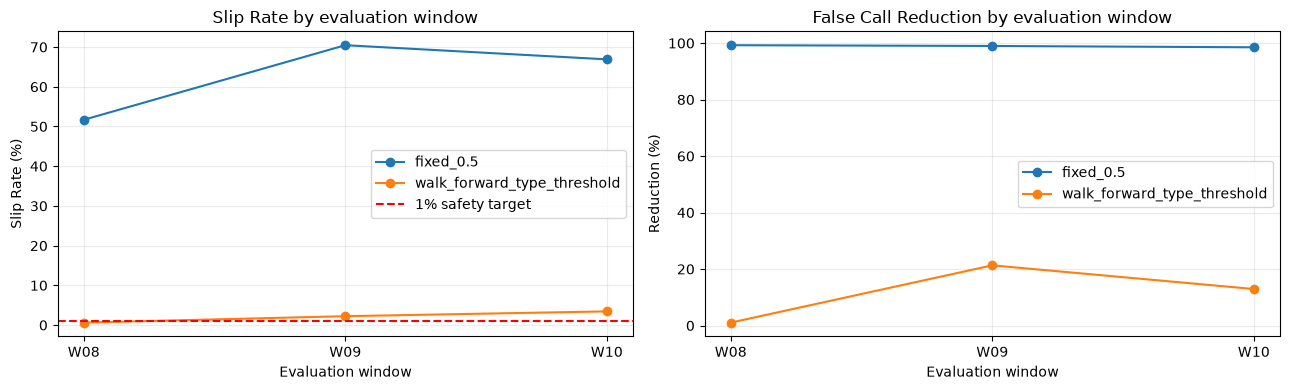

In [10]:
plot_df = window_policy_summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for policy, group in plot_df.groupby("policy"):
    axes[0].plot(group["evaluation_window"], group["slip_rate"] * 100, marker="o", label=policy)
    axes[1].plot(group["evaluation_window"], group["volume_reduction"] * 100, marker="o", label=policy)
axes[0].axhline(MAX_SLIP_RATE * 100, color="red", linestyle="--", label="1% safety target")
axes[0].set_title("Slip Rate by evaluation window")
axes[0].set_ylabel("Slip Rate (%)")
axes[1].set_title("False Call Reduction by evaluation window")
axes[1].set_ylabel("Reduction (%)")
for ax in axes:
    ax.set_xlabel("Evaluation window")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## 9. 결론

결론은 전체 실행 결과에서 자동 생성합니다.

In [11]:
fixed = aggregate_policy_summary.loc["fixed_0.5"]
walk = aggregate_policy_summary.loc["walk_forward_type_threshold"]
window_walk = window_policy_summary.xs("walk_forward_type_threshold", level="policy")
updates = int((threshold_history["source"] == "updated").sum())
fallbacks = len(threshold_history) - updates
type_targets_met = int(walk_forward_type["safety_target_met"].sum())

conclusion = f"""
### 실행 결과

- 고정 `kimjaehak_006` 모델의 W09~W10 PR-AUC는 **{reproduced_006['pr_auc']:.6f}**, Recall은 **{reproduced_006['recall']:.6f}**로 기존 결과를 재현했습니다.
- W08~W10 전체에서 고정 0.5 정책은 Slip Rate **{fixed['slip_rate']:.2%}**, False Call Reduction **{fixed['volume_reduction']:.2%}**였습니다.
- 직전 구간 type별 threshold 정책은 Slip Rate **{walk['slip_rate']:.2%}**, False Call Reduction **{walk['volume_reduction']:.2%}**였습니다.
- 변화량은 TN **{int(walk['tn'] - fixed['tn']):+,}건**, FN **{int(walk['fn'] - fixed['fn']):+,}건**입니다.
- 총 15번의 type×구간 threshold 결정 중 표본 조건을 만족해 갱신한 경우는 **{updates}번**, fallback 또는 이전 값 유지가 **{fallbacks}번**이었습니다.
- type×평가구간 15개 중 실제 Slip Rate 1% 목표를 만족한 경우는 **{type_targets_met}개**였습니다.
- 구간별 walk-forward Slip Rate는 W08 **{window_walk.loc['W08', 'slip_rate']:.2%}**, W09 **{window_walk.loc['W09', 'slip_rate']:.2%}**, W10 **{window_walk.loc['W10', 'slip_rate']:.2%}**입니다.

### 판정

이 실험은 threshold를 미래 데이터에 맞춰 다시 고르지 않고 직전 구간 값으로 고정 적용했습니다. 따라서 직전 구간에서 1%를 만족했다는 사실만으로 다음 구간에서도 안전하다고 보장할 수 있는지, 그리고 그 대가로 재검사를 얼마나 줄일 수 있는지를 함께 판단해야 합니다.

다음 독립 실험에서는 같은 고정 모델에 확률 calibration을 적용하고, 비용비율로 사전에 정한 고정 확률 threshold를 사용합니다. raw score에서 type별 threshold를 직접 선택한 이번 결과와 섞지 않고 비교합니다.
"""
display(Markdown(conclusion))


### 실행 결과

- 고정 `kimjaehak_006` 모델의 W09~W10 PR-AUC는 **0.315411**, Recall은 **0.316141**로 기존 결과를 재현했습니다.
- W08~W10 전체에서 고정 0.5 정책은 Slip Rate **66.27%**, False Call Reduction **98.92%**였습니다.
- 직전 구간 type별 threshold 정책은 Slip Rate **2.64%**, False Call Reduction **11.69%**였습니다.
- 변화량은 TN **-100,320건**, FN **-1,639건**입니다.
- 총 15번의 type×구간 threshold 결정 중 표본 조건을 만족해 갱신한 경우는 **9번**, fallback 또는 이전 값 유지가 **6번**이었습니다.
- type×평가구간 15개 중 실제 Slip Rate 1% 목표를 만족한 경우는 **9개**였습니다.
- 구간별 walk-forward Slip Rate는 W08 **0.61%**, W09 **2.23%**, W10 **3.44%**입니다.

### 판정

이 실험은 threshold를 미래 데이터에 맞춰 다시 고르지 않고 직전 구간 값으로 고정 적용했습니다. 따라서 직전 구간에서 1%를 만족했다는 사실만으로 다음 구간에서도 안전하다고 보장할 수 있는지, 그리고 그 대가로 재검사를 얼마나 줄일 수 있는지를 함께 판단해야 합니다.

다음 독립 실험에서는 같은 고정 모델에 확률 calibration을 적용하고, 비용비율로 사전에 정한 고정 확률 threshold를 사용합니다. raw score에서 type별 threshold를 직접 선택한 이번 결과와 섞지 않고 비교합니다.
